<a href="https://colab.research.google.com/github/Kunal-7O7/Machine-Learning-Algorithms/blob/main/XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df_ma=sns.load_dataset("titanic")

In [3]:
#Copying the dataset for EDA
df=df_ma.copy()

In [4]:
#Basic EDA on the Dataset

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
# Removing the Useless features

df=df.drop(["class","who","adult_male","embark_town","deck","alive"],axis=1)

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [8]:
df["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [9]:
# filling missing values

df["age"]=df["age"].fillna(df["age"].median())
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

In [10]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
alone,0


In [11]:
for col in ["sex","embarked"]:
  df[col]=df[col].map({"male":1,"female":0,"C":0,"S":2,"Q":1})

In [12]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


In [13]:
x=df.drop("survived",axis=1)
y=df["survived"]

In [14]:
x.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,1,22.0,1,0,7.2500,2,False
1,1,0,38.0,1,0,71.2833,0,False
2,3,0,26.0,0,0,7.9250,2,True
3,1,0,35.0,1,0,53.1000,2,False
4,3,1,35.0,0,0,8.0500,2,True


In [15]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [17]:
model=XGBClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [18]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7877094972067039
[[86 19]
 [19 55]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [19]:
# Now we are tuning the hyperparameters in xgboostclassifier

mode1=XGBClassifier(n_estimators=100,
                    max_depth=10,
                    learning_rate=.02,

                    )

In [20]:
mode1.fit(x_train,y_train)
y_pred=mode1.predict(x_test)

In [21]:
cm=confusion_matrix(y_test,y_pred)

In [22]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8324022346368715
[[96  9]
 [21 53]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       105
           1       0.85      0.72      0.78        74

    accuracy                           0.83       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



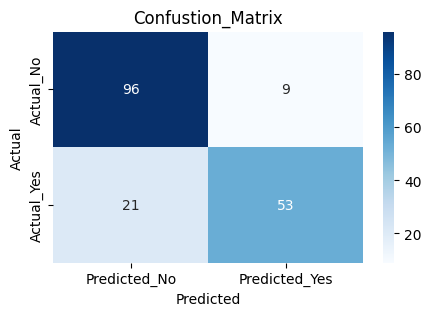

In [23]:
# Showing the Cm
plt.figure(figsize=(5,3))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Predicted_No","Predicted_Yes"],
            yticklabels=["Actual_No","Actual_Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confustion_Matrix")

plt.show()


In [36]:
x_train

,pclass,sex,age,sibsp,parch,fare,embarked,alone
331,1,1,45.5,0,0,28.5000,2,True
733,2,1,23.0,0,0,13.0000,2,True
382,3,1,32.0,0,0,7.9250,2,True
704,3,1,26.0,1,0,7.8542,2,False
813,3,0,6.0,4,2,31.2750,2,False
...,...,...,...,...,...,...,...,...
106,3,0,21.0,0,0,7.6500,2,True
270,1,1,28.0,0,0,31.0000,2,True
860,3,1,41.0,2,0,14.1083,2,False
435,1,0,14.0,1,2,120.0000,2,False


In [37]:
# Compareing training and testing accuracy


y_train_pred=model.predict(x_train)



In [39]:
print("Training Accuracy:",accuracy_score(y_train,y_train_pred))
print("Testing_Accuracy:",accuracy_score(y_test,y_pred))

Training Accuracy: 0.9634831460674157
Testing_Accuracy: 0.8324022346368715


In [41]:
# As we can see that the model's traning accuracy is 96 but the testing accuracy is only 83% this is a clear sign of the overfitting
# model is not leaning it is just memorising the value's therefore we are cheking the features inportance.

importance=model.feature_importances_

importanc_df=pd.DataFrame({"feature":x_train.columns,
                           "importance":importance})

In [43]:
importanc_df

,feature,importance
0,pclass,0.193749
1,sex,0.580601
2,age,0.032891
3,sibsp,0.072734
4,parch,0.029127
5,fare,0.032449
6,embarked,0.031950
7,alone,0.026499


In [45]:
importance_df=importanc_df.sort_values(by="importance",ascending=False)

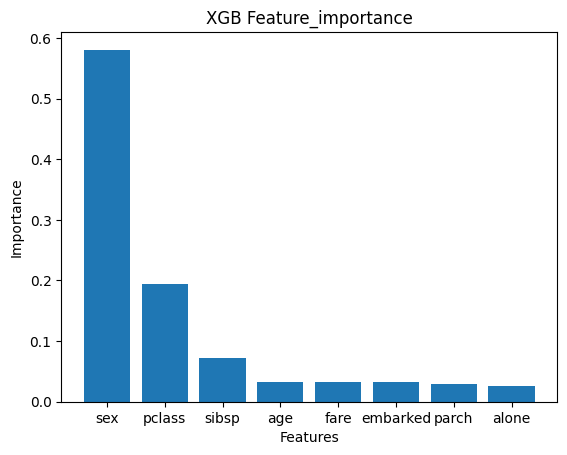

In [63]:
plt.bar(importance_df["feature"],
        importance_df["importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGB Feature_importance")

plt.show()

In [85]:
# for finding the best parameteres will go with grid searchCV

from sklearn.model_selection import GridSearchCV
grid={"n_estimators":[100,50,300],
      "max_depth":[3,5,7],
      "learning_rate":[.001,.1,.10],
      "reg_alpha":[.001,.05,.03],
      "subsample":[.80,.90]}

In [86]:
Model=GridSearchCV(model,grid,cv=5,n_jobs=-1)

In [87]:
Model.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.1, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 50, 300],
                         'reg_alpha': [0.001, 0.05, 0.03],
                         'subsample': [0.8, 0.9]})

In [88]:
print(Model.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'reg_alpha': 0.001, 'subsample': 0.9}


In [89]:
print(Model.best_score_)

0.8384615384615384


In [129]:
model3=XGBClassifier(n_estimarors=200,
                     max_depth=6,
                     learning_rate=.04)

In [130]:
model3.fit(x_train,y_train)
y_pred=model3.predict(x_test)

In [131]:
print(accuracy_score(y_test,y_pred))

0.8435754189944135


In [134]:
# final accuracy
print(accuracy_score(y_test,y_pred))

0.8435754189944135
